<a href="https://colab.research.google.com/github/divyadharshini-1306/ShiftSafeAI/blob/main/ShiftSAfeAI_xgboost_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Always mount Drive first in every new Colab notebook
# Without this, Colab cannot see your saved files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# pandas — for loading and manipulating the DataFrame
import pandas as pd

# numpy — for numerical operations like array math
import numpy as np

# matplotlib — the base plotting library
import matplotlib.pyplot as plt

# XGBRegressor — the XGBoost model for regression (predicting a number)
# We use Regressor because AQI is a continuous number, not a category
# If we were predicting "Good/Moderate/Poor" it would be XGBClassifier instead
from xgboost import XGBRegressor

# These three are evaluation metrics from scikit-learn
# mean_absolute_error — average of |predicted - actual|
# mean_squared_error  — average of (predicted - actual)², then we sqrt it for RMSE
# r2_score            — % of AQI variation explained by the model (0 to 1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the clean file — this is the only file we touch from here on
df = pd.read_csv('/content/drive/MyDrive/ShiftSafe_AI/XGBOOST_Model/blr_clean.csv')

# Convert Datetime back to proper datetime format
# (CSV files store everything as text, so we convert it back)
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Sort by time — critical for time series
# We must ensure rows are in chronological order before splitting
df = df.sort_values('Datetime').reset_index(drop=True)

# Quick confirmation
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['Datetime'].min()} → {df['Datetime'].max()}")

Loaded: 48189 rows, 20 columns
Date range: 2015-01-01 04:00:00 → 2020-07-01 00:00:00


In [ ]:
# TARGET VARIABLE — what the model must predict
#
# Right now every row tells us: "at this hour, AQI was X"
# But we want to predict: "at the NEXT hour, AQI will be X"
#
# We create AQI_next by shifting the AQI column up by 1 row
# shift(-1) moves everything up by one position:
#   Row 0's AQI_next = Row 1's AQI  (next hour)
#   Row 1's AQI_next = Row 2's AQI  (next hour)
#   ...and so on
#
# The very last row has no "next hour" so it becomes NaN
# We drop that one row with dropna()

df['AQI_next'] = df['AQI'].shift(-1)

# Drop the last row which has NaN in AQI_next
df = df.dropna(subset=['AQI_next']).reset_index(drop=True)

print(f"Rows after creating target: {len(df)}")
print(f"\nSample — current AQI vs next hour AQI:")

# Show a few rows to visually confirm the shift worked correctly
# AQI_next in row 0 should equal AQI in row 1
print(df[['Datetime', 'AQI', 'AQI_next']].head(5).to_string(index=False))

Rows after creating target: 48188

Sample — current AQI vs next hour AQI:
           Datetime   AQI  AQI_next
2015-01-01 04:00:00  76.4     108.2
2015-01-01 05:00:00 108.2      55.6
2015-01-01 06:00:00  55.6      88.8
2015-01-01 07:00:00  88.8      91.8
2015-01-01 08:00:00  91.8      88.8


In [ ]:
# FEATURES — the columns the model is allowed to see as inputs
#
# We include:
# - Raw pollutant readings: PM2.5, PM10, NO, NO2, NH3, CO, SO2, O3
#   These are the current hour's air quality measurements
# - Time features: hour, month, day_of_week, is_weekend, is_shift_hour
#   These tell the model what time it is so it can learn time patterns
# - Engineered features: AQI_lag1, AQI_lag3, PM25_rolling6, AQI_rolling6
#   These give the model recent history and trend information
#
# We DO NOT include:
# - 'City' — it's a text value, not a number, and all rows are Bengaluru anyway
# - 'Datetime' — it's a timestamp, not a numeric signal
# - 'AQI' — this is the current hour's AQI, which the model should use as input
#   (via AQI_lag1 which IS the current AQI when predicting next hour)
# - 'AQI_next' — this is the TARGET (y), never an input

feature_cols = [
    # Raw pollutants — what the air contains right now
    'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3',
    # Time signals — when is this happening
    'hour', 'month', 'day_of_week', 'is_weekend', 'is_shift_hour',
    # Recent history — what was happening before this hour
    'AQI_lag1', 'AQI_lag3', 'PM25_rolling6', 'AQI_rolling6'
]

# X is the input matrix — all feature columns, all rows
# y is the output vector — just AQI_next, all rows
X = df[feature_cols]
y = df['AQI_next']

print(f"X shape: {X.shape}")  # Should be (48188, 17)
print(f"y shape: {y.shape}")  # Should be (48188,)
print(f"\nFeature columns ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

X shape: (48188, 17)
y shape: (48188,)

Feature columns (17 total):
   1. PM2.5
   2. PM10
   3. NO
   4. NO2
   5. NH3
   6. CO
   7. SO2
   8. O3
   9. hour
  10. month
  11. day_of_week
  12. is_weekend
  13. is_shift_hour
  14. AQI_lag1
  15. AQI_lag3
  16. PM25_rolling6
  17. AQI_rolling6


In [ ]:
# TRAIN/TEST SPLIT — the most important step to get right
#
# We take 80% of rows as training data and 20% as test data
# CRITICAL: we do NOT shuffle — we split in time order
#
# Why no shuffling?
# If we shuffled, row 30000 (year 2018) could end up in test
# and row 30001 (one hour later, 2018) ends up in training.
# The model would have seen data from AFTER the test point during training.
# This is called "data leakage" and gives falsely high accuracy.
#
# Correct approach: train on the past, test on the future
# Training set: 2015 → early 2019 (~38,550 rows)
# Test set:     early 2019 → mid 2020 (~9,638 rows)

# Calculate the split index — 80% of total rows
split_index = int(len(X) * 0.80)

# Slice: everything BEFORE split_index = train
#        everything FROM split_index onward = test
X_train = X.iloc[:split_index]   # iloc = integer location based indexing
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# The dates help us confirm the split happened at the right time boundary
train_end_date = df['Datetime'].iloc[split_index - 1]
test_start_date = df['Datetime'].iloc[split_index]

print(f"Training set:  {len(X_train):,} rows")
print(f"Test set:      {len(X_test):,} rows")
print(f"\nTraining period ends:  {train_end_date}")
print(f"Test period starts:    {test_start_date}")
print(f"\nTrain/test ratio: {len(X_train)/len(X)*100:.1f}% / {len(X_test)/len(X)*100:.1f}%")

Training set:  38,550 rows
Test set:      9,638 rows

Training period ends:  2019-05-26 09:00:00
Test period starts:    2019-05-26 10:00:00

Train/test ratio: 80.0% / 20.0%


In [ ]:
# TRAIN THE MODEL
#
# XGBRegressor parameters explained:
#
# n_estimators=200
#   How many trees to build sequentially
#   Each new tree corrects the errors of all previous trees
#   200 is a good balance between accuracy and training speed
#
# learning_rate=0.05
#   How much each new tree is allowed to correct previous ones
#   Small value (0.05) = careful, small corrections = less overfitting
#   Large value (0.3) = aggressive corrections = might overfit
#
# max_depth=6
#   How many yes/no decisions each tree can make
#   Depth 6 means each tree can split the data 6 times
#   Too deep (>10) = model memorises training data = bad on new data
#
# subsample=0.8
#   Each tree is trained on a random 80% of training rows
#   This randomness prevents trees from being too similar = less overfitting
#
# colsample_bytree=0.8
#   Each tree only sees a random 80% of feature columns
#   Again adds randomness to make trees more diverse and robust
#
# random_state=42
#   Sets a fixed seed for reproducibility
#   With the same seed, you get the same result every time you run
#   Without it, slight differences appear each run due to randomness
#
# verbosity=0
#   Suppresses XGBoost's internal print messages
#   Set to 1 if you want to see training progress

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

# .fit() is where actual training happens
# The model reads X_train and y_train 200 times (once per tree)
# and learns the relationship between features and AQI_next
print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Training complete.")

Training XGBoost model...
Training complete.


In [ ]:
# MAKE PREDICTIONS ON TEST SET
#
# .predict() takes the test features (X_test) and returns
# an array of predicted AQI_next values — one per row
# The model has NEVER seen X_test during training
# So this is a genuine test of how well it learned

y_pred = model.predict(X_test)

# CALCULATE EVALUATION METRICS
#
# MAE — Mean Absolute Error
# Average of |predicted - actual| across all test rows
# Interpretation: "on average my predictions are X AQI points off"
mae = mean_absolute_error(y_test, y_pred)

# RMSE — Root Mean Squared Error
# sqrt(average of (predicted - actual)²)
# Penalises large errors more than small ones
# Always >= MAE. A big gap between RMSE and MAE means occasional large errors
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# R² — R-squared (coefficient of determination)
# How much of the AQI variation does the model explain?
# 1.0 = perfect, 0.0 = no better than predicting the mean every time
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("      MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE:   {mae:.2f}  AQI points avg error")
print(f"  RMSE:  {rmse:.2f}  AQI points (penalises big errors)")
print(f"  R²:    {r2:.4f}  ({r2*100:.1f}% of variation explained)")
print("=" * 40)

# Interpret the results automatically
if r2 >= 0.85:
    print("\n Excellent model — R² above 0.85")
elif r2 >= 0.75:
    print("\n Good model — R² above 0.75")
elif r2 >= 0.60:
    print("\n  Acceptable model — consider adding more features")
else:
    print("\n Weak model — check feature columns and data quality")

      MODEL EVALUATION RESULTS
  MAE:   3.55  AQI points avg error
  RMSE:  5.05  AQI points (penalises big errors)
  R²:    0.9445  (94.4% of variation explained)

 Excellent model — R² above 0.85


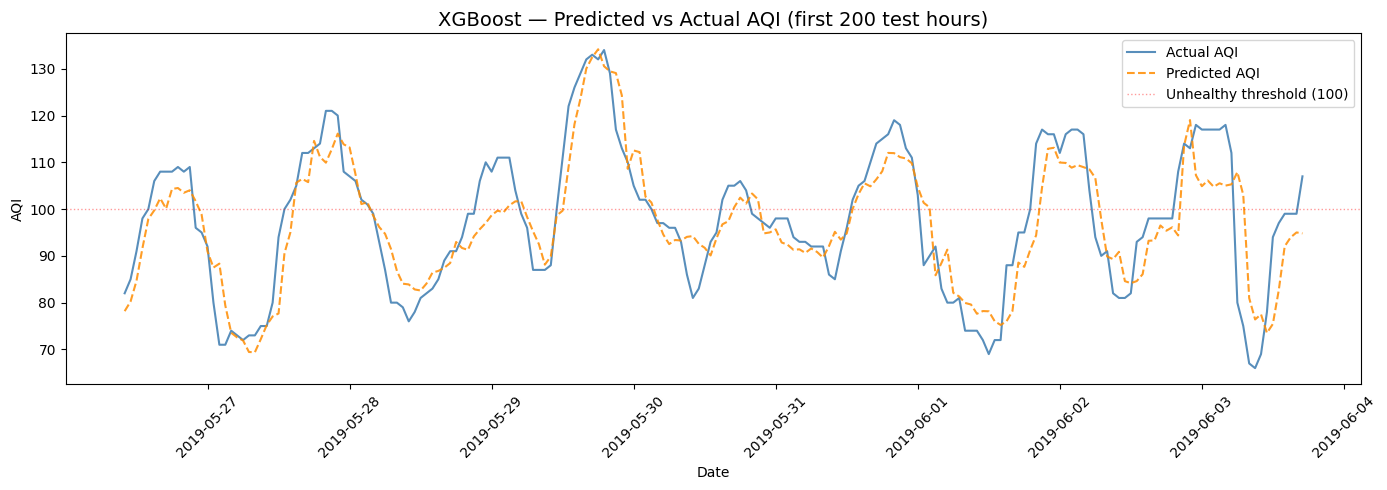

Sample predictions vs actual values:
Hour       Actual    Predicted    Error
----------------------------------------
0            82.0         78.2      3.8
1            85.0         80.3      4.7
2            91.0         84.7      6.3
3            98.0         91.6      6.4
4           100.0         97.9      2.1
5           106.0         99.7      6.3
6           108.0        102.3      5.7
7           108.0        100.1      7.9
8           108.0        104.3      3.7
9           109.0        104.5      4.5


In [ ]:
# PREDICTED VS ACTUAL PLOT
#
# This is the most honest visual check of model performance.
# We plot two lines on the same chart:
# - Blue line: what the AQI actually was (ground truth)
# - Orange line: what our model predicted
#
# A good model: orange line closely follows blue line
# A bad model:  orange line is flat, always late, or wildly off
#
# We only plot the first 200 test hours (not all 9,638)
# because plotting all rows makes the chart unreadable

n_display = 200  # number of test hours to display

# Create the date axis for the x-axis
# We grab the Datetime values from df that correspond to the test rows
test_dates = df['Datetime'].iloc[split_index:split_index + n_display]

fig, ax = plt.subplots(figsize=(14, 5))

# Plot actual AQI — solid blue line
ax.plot(test_dates,
        y_test.values[:n_display],
        color='steelblue', linewidth=1.5,
        label='Actual AQI', alpha=0.9)

# Plot predicted AQI — dashed orange line
# alpha=0.85 makes it slightly transparent so both lines are visible
ax.plot(test_dates,
        y_pred[:n_display],
        color='darkorange', linewidth=1.5,
        linestyle='--', label='Predicted AQI', alpha=0.85)

# Add threshold lines for context
ax.axhline(100, color='red', linestyle=':', alpha=0.4, linewidth=1, label='Unhealthy threshold (100)')

ax.set_title('XGBoost — Predicted vs Actual AQI (first 200 test hours)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend(loc='upper right')

# Rotate x-axis dates so they don't overlap
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print a few specific predictions vs actuals so you can see exact numbers
print("Sample predictions vs actual values:")
print(f"{'Hour':<6} {'Actual':>10} {'Predicted':>12} {'Error':>8}")
print("-" * 40)
for i in range(10):
    actual = y_test.values[i]
    predicted = y_pred[i]
    error = abs(actual - predicted)
    print(f"{i:<6} {actual:>10.1f} {predicted:>12.1f} {error:>8.1f}")

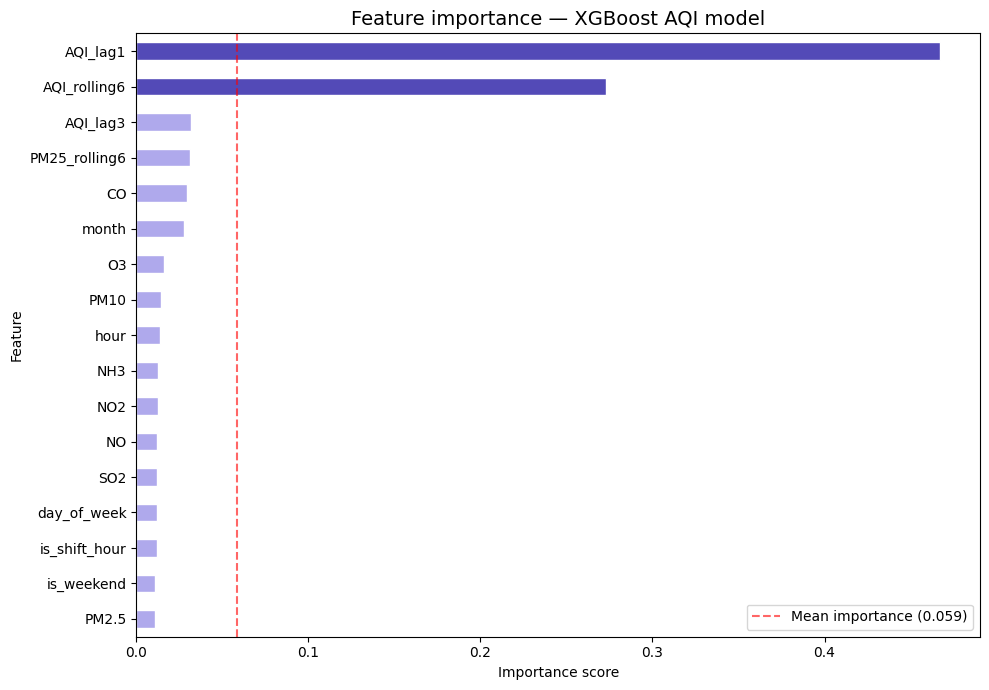

Feature importance ranking (most important first):
---------------------------------------------
   1. AQI_lag1           0.4670  █████████████████████████████████████████████████████████████████████████████████████████████
   2. AQI_rolling6       0.2729  ██████████████████████████████████████████████████████
   3. AQI_lag3           0.0320  ██████
   4. PM25_rolling6      0.0313  ██████
   5. CO                 0.0293  █████
   6. month              0.0276  █████
   7. O3                 0.0161  ███
   8. PM10               0.0145  ██
   9. hour               0.0138  ██
  10. NH3                0.0126  ██
  11. NO2                0.0124  ██
  12. NO                 0.0122  ██
  13. SO2                0.0122  ██
  14. day_of_week        0.0121  ██
  15. is_shift_hour      0.0120  ██
  16. is_weekend         0.0112  ██
  17. PM2.5              0.0108  ██


In [ ]:
# FEATURE IMPORTANCE
#
# XGBoost internally tracks how much each feature reduced
# prediction error across all 200 trees.
# Features used more often for important splits get higher scores.
#
# This chart answers: which of your 17 input columns
# did the model actually rely on most?
#
# Expected finding based on your EDA:
# - AQI_lag1 and AQI_rolling6 should rank very high
#   (recent AQI history is the strongest signal)
# - PM2.5 should also rank high (confirmed by your correlation heatmap)
# - is_shift_hour appearing in the chart validates your project's premise

# Extract importance scores from the trained model
# feature_importances_ is a numpy array with one score per feature
importances = pd.Series(
    model.feature_importances_,  # array of importance scores
    index=feature_cols            # label each score with its column name
)

# Sort from least to most important (ascending)
# so the most important appears at the TOP of the horizontal bar chart
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

# Create horizontal bar chart
# barh = bar chart rotated 90 degrees (horizontal bars)
colors = ['#534AB7' if imp > importances.mean()
          else '#AFA9EC'
          for imp in importances_sorted]
# Dark purple = above average importance
# Light purple = below average importance

importances_sorted.plot(
    kind='barh',
    ax=ax,
    color=colors,
    edgecolor='white'
)

# Add a vertical line at the mean importance
# Features to the right of this line are above-average contributors
ax.axvline(importances.mean(),
           color='red', linestyle='--', alpha=0.6,
           label=f'Mean importance ({importances.mean():.3f})')

ax.set_title('Feature importance — XGBoost AQI model', fontsize=14)
ax.set_xlabel('Importance score')
ax.set_ylabel('Feature')
ax.legend()
plt.tight_layout()
plt.show()

# Print the ranking clearly
print("Feature importance ranking (most important first):")
print("-" * 45)
importances_ranked = importances.sort_values(ascending=False)
for rank, (feature, score) in enumerate(importances_ranked.items(), 1):
    bar = '█' * int(score * 200)  # visual bar in text
    print(f"  {rank:2d}. {feature:<18} {score:.4f}  {bar}")
#top 3 features:AQI_lag1,2. AQI_rolling6 ,3. AQI_lag3
#reference these in your paper and in your team update.

In [ ]:
import pickle
import json

# SAVE THE TRAINED MODEL
#
# pickle serialises the trained model object into a binary file
# This means you don't have to retrain every time you restart Colab
# Aadish will load this exact file in his FastAPI backend

model_path = '/content/drive/MyDrive/ShiftSafe_AI/models/xgboost_aqi_model.pkl'

# Create the models folder if it doesn't exist
import os
os.makedirs('/content/drive/MyDrive/ShiftSafe_AI/models', exist_ok=True)

# wb = write binary — pickle files are binary not text
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model saved to: {model_path}")

# SAVE FEATURE COLUMN NAMES
#
# Aadish needs to know the exact column names and order
# that the model expects as input.
# If he passes columns in the wrong order, predictions will be wrong.
# We save this as a JSON file alongside the model.

feature_path = '/content/drive/MyDrive/ShiftSafe_AI/models/feature_cols.json'
with open(feature_path, 'w') as f:
    json.dump(feature_cols, f)

print(f"Feature columns saved to: {feature_path}")

# WRAP MODEL AS A CALLABLE FUNCTION
#
# This is the exact function Aadish will import into his FastAPI backend.
# It takes a dictionary of feature values and returns a predicted AQI.
# We define and test it here so we know it works before handing it off.

def predict_aqi(feature_dict: dict) -> float:
    """
    Takes a dictionary of current hour's features
    and returns the predicted AQI for the next hour.

    feature_dict must contain all 17 feature keys in any order.
    Returns a single float — the predicted next-hour AQI.
    """
    # Convert the dict to a DataFrame with one row
    # The model.predict() expects a 2D array or DataFrame, not a plain dict
    input_df = pd.DataFrame([feature_dict])

    # Ensure columns are in the exact order the model was trained on
    # Column order matters — wrong order = wrong predictions
    input_df = input_df[feature_cols]

    # Make prediction — returns an array of 1 value, we take index [0]
    prediction = model.predict(input_df)[0]

    # Round to 1 decimal place — AQI is not reported to 6 decimal places
    return round(float(prediction), 1)


# TEST THE FUNCTION with a sample input
# We take the first row of X_test as a realistic test case
sample_input = X_test.iloc[0].to_dict()
sample_actual = y_test.iloc[0]

predicted = predict_aqi(sample_input)

print("\n" + "=" * 45)
print("  predict_aqi() FUNCTION TEST")
print("=" * 45)
print(f"  Input hour:      {df['Datetime'].iloc[split_index]}")
print(f"  Actual AQI next: {sample_actual:.1f}")
print(f"  Predicted AQI:   {predicted}")
print(f"  Error:           {abs(sample_actual - predicted):.1f} AQI points")
print("=" * 45)
print("\nFunction works correctly. Ready for Aadish's API.")

Model saved to: /content/drive/MyDrive/ShiftSafe_AI/models/xgboost_aqi_model.pkl
Feature columns saved to: /content/drive/MyDrive/ShiftSafe_AI/models/feature_cols.json

  predict_aqi() FUNCTION TEST
  Input hour:      2019-05-26 10:00:00
  Actual AQI next: 82.0
  Predicted AQI:   78.2
  Error:           3.8 AQI points

Function works correctly. Ready for Aadish's API.
